In [1]:
import torch

import pandas as pd
data_folder = '../../data/'
social_vuln = data_folder + "California_county_social_vuln_2018.csv"
data_CCSV=pd.read_csv(social_vuln)
data_HUS=pd.read_csv(data_folder + "healthcare utilization summary data.csv")
print(data_CCSV.head())

   ST       STATE ST_ABBR     COUNTY  FIPS                      LOCATION  \
0   6  CALIFORNIA      CA     Sierra  6091     Sierra County, California   
1   6  CALIFORNIA      CA     Placer  6061     Placer County, California   
2   6  CALIFORNIA      CA  El Dorado  6017  El Dorado County, California   
3   6  CALIFORNIA      CA     Nevada  6057     Nevada County, California   
4   6  CALIFORNIA      CA       Mono  6051       Mono County, California   

     AREA_SQMI  E_TOTPOP  M_TOTPOP    E_HU  ...  F_CROWD  F_NOVEH  F_GROUPQ  \
0   953.167917      2930       161    2395  ...        0        0         0   
1  1407.081272    380077         0  161846  ...        0        0         0   
2  1707.841296    186661         0   89763  ...        0        0         0   
3   957.759727     99092         0   53654  ...        0        0         0   
4  3048.985133     14174         0   14078  ...        0        0         0   

   F_THEME4  F_TOTAL  E_UNINSUR  M_UNINSUR  EP_UNINSUR  MP_UNINSUR  

In [2]:
#AreaID	Geographic area identifier, created by Milliman to statistically de-identify the data provided to the hackathon. Each area includes several adjacent counties. Refer to the "FIPS to AreaID Crosswalk" table. If field value is missing, the area is deemed unknown due to underlying data quality issues
# yearmo	Year-month
# LOB	Health insurance coverage type. ADV = Medicare Advantage. COM = Commercial. MCD = Medicaid
# RiskScore	Average health status risk score, generated by Milliman using the industry standard risk adjustment tool, MARA (https://www.milliman.com/en/products/mara). The higher the risk score, the greater healthcare resource needs. 
# E_UNINSUR	Estimated uninsured persons
# MED_ADMT_CNT	Count of medical admissions
# ED_ADMT_CNT	Count of emergency department visits
# UC_ADMT_CNT	Count of urgent care visits

HUS_cols=["AreaID", "LOB", "RiskScore", "E_UNINSUR", "MED_ADMT_CNT", "ED_ADMT_CNT", "UC_ADMT_CNT", "yearmo"]
print(data_HUS[HUS_cols].head())
reduced_HUS=data_HUS[HUS_cols]


  AreaID  LOB  RiskScore  E_UNINSUR  MED_ADMT_CNT  ED_ADMT_CNT  UC_ADMT_CNT  \
0    CA1  ADV   0.560346     279602           477          432          590   
1   CA10  ADV   1.089814      44779             0            1            0   
2   CA11  ADV   1.091538      10946             0            1            0   
3   CA12  ADV   1.196100      92035             1            2            2   
4   CA13  ADV   1.128039      24903             2           10            0   

   yearmo  
0  201701  
1  201701  
2  201701  
3  201701  
4  201701  


In [3]:
fips_to_ac = pd.read_csv(data_folder + "area_code_to_fips.csv")
only_fips = pd.merge(data_HUS[HUS_cols], fips_to_ac, on="AreaID", how="left")
only_fips.drop("AreaID", axis=1, inplace=True)

In [4]:
# Here we calculate the socioeconomic status score by county by summing the proportion of vulnerable socioeconomic indicators

if social_vuln == data_folder + "California_county_social_vuln_2018.csv":
    cols = ["E_POV", "E_UNEMP", "E_NOHSDP", "E_UNINSUR"]
    for col in cols:
        data_CCSV[f"{col}_prop"] = data_CCSV[col] / data_CCSV["E_TOTPOP"]

    data_CCSV["Socioeconomic_status"] = data_CCSV[["E_UNEMP_prop", "E_POV_prop", "E_NOHSDP_prop", "E_UNINSUR_prop"]].sum(axis=1)
    data_CCSV['Year'] = 2018
    print(data_CCSV.columns)
elif social_vuln == data_folder + "California_county_social_vuln_2022.csv":
    cols = ["E_POV150", "E_UNEMP", "E_HBURD", "E_NOHSDP", "E_UNINSUR"]
    for col in cols:
        data_CCSV[f"{col}_prop"] = data_CCSV[col] / data_CCSV["E_TOTPOP"]

    data_CCSV["Socioeconomic_status"] = data_CCSV[["E_UNEMP_prop", "E_POV150_prop", "E_HBURD_prop", "E_NOHSDP_prop", "E_UNINSUR_prop"]].sum(axis=1)
    data_CCSV['Year'] = 2022
    print(data_CCSV[["COUNTY","Socioeconomic_status"]].head())

Index(['ST', 'STATE', 'ST_ABBR', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI',
       'E_TOTPOP', 'M_TOTPOP', 'E_HU',
       ...
       'M_UNINSUR', 'EP_UNINSUR', 'MP_UNINSUR', 'E_DAYPOP', 'E_POV_prop',
       'E_UNEMP_prop', 'E_NOHSDP_prop', 'E_UNINSUR_prop',
       'Socioeconomic_status', 'Year'],
      dtype='object', length=129)


In [5]:
data_CCSV_2016=pd.read_csv(data_folder + "California_county_social_vuln_2016.csv")
cols = ["E_POV", "E_UNEMP", "E_NOHSDP", "E_UNINSUR"]
for col in cols:
    data_CCSV_2016[f"{col}_prop"] = data_CCSV_2016[col] / data_CCSV_2016["E_TOTPOP"]

data_CCSV_2016["Socioeconomic_status"] = data_CCSV_2016[["E_UNEMP_prop", "E_POV_prop", "E_NOHSDP_prop", "E_UNINSUR_prop"]].sum(axis=1)
data_CCSV_2016['Year'] = 2016
data_CCSV_combined = pd.concat([data_CCSV, data_CCSV_2016], ignore_index=True)
reduced = data_CCSV_combined[["COUNTY","Socioeconomic_status", 'Year', 'FIPS']]

      COUNTY  Socioeconomic_status
5      Marin              0.182965
1     Placer              0.188391
7  San Mateo              0.217657
2  El Dorado              0.219500
8     Plumas              0.223702


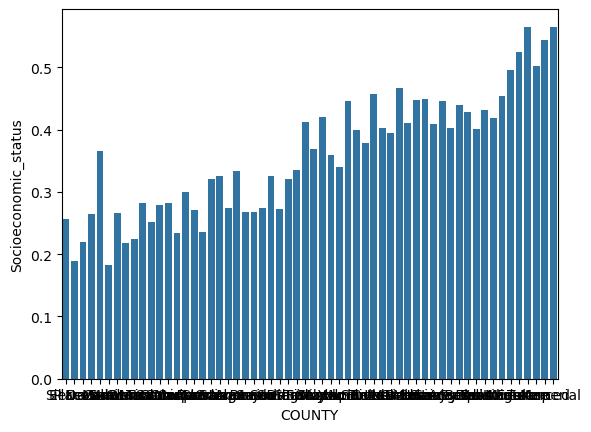

In [6]:
# Some basic visualizing and sorting
import seaborn as sns
sns.barplot(data_CCSV, x="COUNTY", y="Socioeconomic_status")
data_ranked_socioeconomic = data_CCSV.sort_values(by="Socioeconomic_status")
print(data_ranked_socioeconomic[["COUNTY","Socioeconomic_status"]].head())

In [7]:
# Here we calculate the demographic score by county by summing the proportion of vulnerable demographics.

cols = ["E_AGE65", "E_AGE17", "E_DISABL", "E_SNGPNT", "E_LIMENG"]
for col in cols:
    data_CCSV[f"{col}_prop"] = data_CCSV[col] / data_CCSV["E_TOTPOP"]
    
data_CCSV["demographic"] = data_CCSV[["E_AGE65_prop", "E_AGE17_prop", "E_DISABL_prop", "E_SNGPNT_prop", "E_LIMENG_prop"]].sum(axis=1)
print(data_CCSV[["COUNTY","demographic"]].head())

      COUNTY  demographic
0     Sierra     0.594881
1     Placer     0.558684
2  El Dorado     0.569814
3     Nevada     0.610463
4       Mono     0.456963


In [8]:
data_ranked_demographic = data_CCSV.sort_values(by="demographic")
print(data_ranked_demographic[["COUNTY","demographic"]].head())

             COUNTY  demographic
23           Lassen     0.445086
4              Mono     0.456963
31             Yolo     0.508459
15    San Francisco     0.514935
9   San Luis Obispo     0.535958


In [9]:
wildfire_data = pd.read_csv(data_folder + 'cleaned_wildfire_data_2017_2019.csv')
wildfire_data.rename(columns={'FIPS_CODE':'FIPS'}, inplace=True)
wildfire_data.head(1)
wildfire_data = wildfire_data[wildfire_data.FIPS < 7000]
wildfire_data = wildfire_data[wildfire_data.FIPS >= 6000]
wildfire_data.shape

(24315, 4)

In [10]:
reduced.shape

(116, 3)

In [11]:
only_fips.shape

(9594, 8)

In [13]:
merged_ccsv_hus = pd.merge(only_fips, reduced, on="FIPS", how="left")
merged_ccsv_hus.head()


,LOB,RiskScore,E_UNINSUR,MED_ADMT_CNT,ED_ADMT_CNT,UC_ADMT_CNT,yearmo,FIPS,COUNTY,Socioeconomic_status,Year
0,ADV,0.560346,279602,477,432,590,201701,6073.0,San Diego,NaN,NaN
1,ADV,0.560346,279602,477,432,590,201701,6073.0,San Diego,0.384499,2016.0
2,ADV,1.089814,44779,0,1,0,201701,6107.0,Tulare,NaN,NaN
3,ADV,1.089814,44779,0,1,0,201701,6107.0,Tulare,0.654380,2016.0
4,ADV,1.091538,10946,0,1,0,201701,6031.0,Kings,NaN,NaN


In [ ]:
merged_ccsv_hus_wf = pd.merge(wildfire_data, merged_ccsv_hus, on="FIPS", how="left")
merged_ccsv_hus_wf

,FIREYEAR,FIRE_SIZE,FIPS,FIPS_NAME,LOB,RiskScore,E_UNINSUR,MED_ADMT_CNT,ED_ADMT_CNT,UC_ADMT_CNT,yearmo,COUNTY,Socioeconomic_status,Year
0,201710,0.1,6051.0,Mono County,ADV,1.128039,24903,2,10,0,201701,Mono,NaN,NaN
1,201710,0.1,6051.0,Mono County,ADV,1.128039,24903,2,10,0,201701,Mono,0.438118,2016.0
2,201710,0.1,6051.0,Mono County,ADV,1.128039,24903,2,2,0,201702,Mono,NaN,NaN
3,201710,0.1,6051.0,Mono County,ADV,1.128039,24903,2,2,0,201702,Mono,0.438118,2016.0
4,201710,0.1,6051.0,Mono County,ADV,1.128039,24903,1,2,0,201703,Mono,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8245059,201909,54608.0,6063.0,Plumas County,MCD,1.325897,9764,1,3,0,201910,Plumas,0.341474,2016.0
8245060,201909,54608.0,6063.0,Plumas County,MCD,1.313432,9764,0,3,0,201911,Plumas,NaN,NaN
8245061,201909,54608.0,6063.0,Plumas County,MCD,1.313432,9764,0,3,0,201911,Plumas,0.341474,2016.0
8245062,201909,54608.0,6063.0,Plumas County,MCD,1.473176,9764,0,6,0,201912,Plumas,NaN,NaN


In [54]:
merged_ccsv_hus_wf.to_csv(data_folder+'Final_merged_dataset.csv', index=False)


In [15]:
merged_ccsv_hus_wf.dropna(axis=1,inplace=True)

In [28]:
merged_ccsv_hus_wf.head(1)
new_df=merged_ccsv_hus_wf.drop('FOP_WO_ED_CNT', axis=1)

KeyError: "['FOP_WO_ED_CNT'] not found in axis"

In [ ]:
MED_ADMT_CNT	FOP_WO_ED_CNT	ED_ADMT_CNT	UC_ADMT_CNT	PCP_VIST_CNT	SPEC_VIST_CNT	ALG_TST_CNT	ALG_IMT_CNT	E_TOTPOP	AREA_SQMI	E_HU	E_HH